<a href="https://colab.research.google.com/github/antonDinkov/AI_Agents_and_Workflows_for_Developers/blob/main/LangChain_Agents_Tools_Exercise_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
!pip install -q langchain langchain-openai langchain-community langchain-chroma langchain-text-splitters

In [125]:
import json
from IPython.display import Image
from langchain.agents import create_agent, AgentState
from langchain.tools import tool
from langchain_openai import ChatOpenAI
from langchain_chroma import Chroma
from langchain_text_splitters import MarkdownHeaderTextSplitter
from langchain_community.document_loaders import TextLoader
from langchain_core.tools import create_retriever_tool
from google.colab import userdata
from langchain.messages import HumanMessage
from langchain_core.messages import BaseMessage
from typing import List
from langchain.agents.middleware.types import after_model, before_model
from langgraph.runtime import Runtime

In [60]:
def print_conversation(messages: List[BaseMessage]) -> None:
  for message in messages:
    message.pretty_print()

In [61]:
api_key_openai = userdata.get("OPEN_AI_API_KEY")
model_instance = ChatOpenAI(
    model="gpt-5.6-luna",
    api_key=api_key_openai,
    use_responses_api=True
)

In [62]:
chroma_db = Chroma(collection_name="faq", persist_directory="/content/chroma")

In [63]:
text_loader = TextLoader(file_path="/content/FAQ.md")
md_header_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=[("#", "Header 1"), ("##", "Question")], strip_headers=False)

In [64]:
documents = text_loader.load()
chunk_to_embed = []
for document in documents:
  chunk_to_embed.extend(md_header_splitter.split_text(document.page_content))

In [65]:
chroma_db.add_documents(chunk_to_embed)

['8b74f060-b3ce-4756-adb6-3de110e4aa37',
 '003e9b96-2081-4612-b4c0-852f02b86ab9',
 'fff5b121-41be-4a4c-bbca-9810b37a57b4',
 '6b3cbafa-1798-456a-80f5-29075260756b',
 '48663c3e-8e71-4742-af7e-a1d4e875665c',
 '9898b88b-ce25-4722-ac89-002d04f6add4',
 '7ae9d41b-18da-46bc-a787-3302575e32f8',
 '88a3823d-5445-4627-aef6-78d6c95bc190',
 '9b148b46-8909-47a8-b54c-0aa0b8ba5f7e',
 'c6148f13-6156-4481-9b2b-651706083a52',
 '9a29c4ec-76db-4c85-8465-5b17d6f4f9a0',
 '80dc895e-aa13-4743-bf84-d984dde6c9ae',
 '7835e897-f428-4f25-a4bb-cd8e5d12edef',
 'c5d0fb7b-968c-468b-91ba-9ea118843173',
 '225cdda7-b382-4a4f-a2ad-28af8b7171b4',
 '83039606-3f89-4a00-8629-e6dd450ea3c4',
 '6ea43006-5ec2-410c-828a-27ab7f7947e9']

In [71]:
''' @tool
def search_database (query: str) -> str:
  """
  Call this tool to search the internal database using a natural language query.
  """
  results = chroma_db.similarity_search(query, k=3)
  return "\n\n------\n\n".join(d.page_content for d in results) '''

chroma_retriever = chroma_db.as_retriever(search_kwargs={"k": 3})
search_database = create_retriever_tool(chroma_retriever, "search_database", "Call this tool to search the internal database using a natural language query.", document_separator="\n\n------\n\n")

In [69]:
print(search_database.invoke("delivery"))

## Q14. Do you deliver on weekends and public holidays?  
Standard processing and delivery times are based on **business days**.  
Orders placed during weekends or public holidays are generally processed on the next business day.  
Weekend delivery may depend on courier availability and the destination.  
---

------

## Q14. Do you deliver on weekends and public holidays?  
Standard processing and delivery times are based on **business days**.  
Orders placed during weekends or public holidays are generally processed on the next business day.  
Weekend delivery may depend on courier availability and the destination.  
---

------

## Q14. Do you deliver on weekends and public holidays?  
Standard processing and delivery times are based on **business days**.  
Orders placed during weekends or public holidays are generally processed on the next business day.  
Weekend delivery may depend on courier availability and the destination.  
---


In [109]:
@tool
def my_orders() -> str:
  """
  Call this tool to retreive all orders of the customer.
  """
  orders = [{"id": 13, "status": "pending"}, {"id": 48, "status": "dellivered"}]
  return json.dumps(orders)



@tool
def lookup_order_details(id: int) -> str:
  """
  Call this tool to lookup additional information about a given order by its id.
  """

  details = {
      13: {"price": 2.57, "vat": 0.39, "product": "blueberies"},
      48: {"price": 5.57, "vat": 1.39, "product": "strawberies"}
  }

  result =  details.get(int(id))
  if result is None:
    return "An order with this id was not found"

  return json.dumps(result)

In [115]:
my_orders.invoke(input="");

In [116]:
lookup_order_details.invoke(input="15")

'An order with this id was not found'

In [142]:
@before_model
def before_model_func (state: AgentState, runtime: Runtime) -> None:
  print("Event: befor_model")
  print(state)
  print(runtime)

@after_model
def after_model_func (state: AgentState, runtime: Runtime) -> None:
  print("Event: after_model")
  print(state)
  print(runtime)
  last_ai_message = state["messages"][-1]

  last_text = next(
        (
            block["text"]
            for block in reversed(last_ai_message.content)
            if block.get("type") == "text"
        ),
        None
    )

  print(f"This is the last message:\n{last_text}")

In [143]:
agent = create_agent(
    model=model_instance,
    tools=[
      search_database,
      my_orders,
      lookup_order_details
    ],
    middleware=[after_model_func, before_model_func],
    system_prompt="You are a helpful customer support agent",
    debug=True
)

In [73]:
answer = agent.invoke(input={"messages": [HumanMessage("Hello! How long should I wait for a standard delivery? Do you offer an express option?")]})

[values] {'messages': [HumanMessage(content='Hello! How long should I wait for a standard delivery? Do you offer an express option?', additional_kwargs={}, response_metadata={}, id='dfb76c68-caad-41db-87d1-d1c50ab7473b')]}
[updates] {'model': {'messages': [AIMessage(content=[{'id': 'rs_02fd2f68ddbd6c95006a8c68cdb8a887d2a0501336c2226345', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqjGjOQb3mUrVn5zKsh1VU7m9t_SZIjA7lcbxl6F9iBUFnywsJ9A2Sava7rvVvSfNEie3mqmXp1-OCkOMZaW64NNJeQFaT2g4mNBkdBxM5nbjHMNCpmanBNNOSuXfWCskstLVGj4LB4LS4PBu3iDFg4R-7GCz4mqvcNyY20t_iNDkyRMXwl_Mc8xrnTHiN5-REjh65YrYZhLZ518ruGTNcT3qGMgdip2X7syBeBSpSGA6PMhbraIMGDYbEqqb0u68BMlTtQ4qsqWgsf-SNJ0Opstg2RvddJn_2MFf0aC7G-xkZlSshbr4K9KYHPlp2jyYYKbW1MG6OoxLlq7AN6yduRX9AC1pcgqitaIqA20IV8tjizOQQ9XdYDEqWDRMmCd5TflT7EQqDmc74hsa0OL-wZOOVb-FIVR2F1XQ-EFU7dnm2BdWsKL-XVc7tdUJvVnkLCyuscOzwMhlV4mcMi2QpwB48YwGn4CRl7qxRkrHDe6w28hjR2PTuGIWZdIepPFOr3BuDn-OHkeguVQen_k4wERn7lwDxrrK3Jn4HLUE38VG48jULlR_1j0CTLeKA0_ErO3i

In [144]:
my_orders_answer = agent.invoke(input={"messages": [HumanMessage("Can you give me a detailed information about my orders?")]})

[values] {'messages': [HumanMessage(content='Can you give me a detailed information about my orders?', additional_kwargs={}, response_metadata={}, id='2de79c31-d83a-4238-85bf-47c668c0112a')]}
Event: befor_model
{'messages': [HumanMessage(content='Can you give me a detailed information about my orders?', additional_kwargs={}, response_metadata={}, id='2de79c31-d83a-4238-85bf-47c668c0112a')]}
Runtime(context=None, store=None, stream_writer=<function Pregel.stream.<locals>.stream_writer at 0x7ebd3bd0b060>, heartbeat=<function _no_op_heartbeat at 0x7ebdc77ef920>, previous=None, execution_info=ExecutionInfo(checkpoint_id='1f19fddd-a738-6ac0-8000-2fd65ab76209', checkpoint_ns='before_model_func.before_model:6462778a-6b50-d44e-f76e-a272a0448fb8', task_id='6462778a-6b50-d44e-f76e-a272a0448fb8', thread_id=None, run_id=None, node_attempt=1, node_first_attempt_time=1787591062.679516), server_info=None, control=<langgraph.runtime.RunControl object at 0x7ebd3c61d4b0>)
[updates] {'before_model_func.b

In [74]:
print_conversation(answer['messages'])

================================ Human Message =================================

Hello! How long should I wait for a standard delivery? Do you offer an express option?
================================== Ai Message ==================================

[{'id': 'rs_02fd2f68ddbd6c95006a8c68cdb8a887d2a0501336c2226345', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqjGjOQb3mUrVn5zKsh1VU7m9t_SZIjA7lcbxl6F9iBUFnywsJ9A2Sava7rvVvSfNEie3mqmXp1-OCkOMZaW64NNJeQFaT2g4mNBkdBxM5nbjHMNCpmanBNNOSuXfWCskstLVGj4LB4LS4PBu3iDFg4R-7GCz4mqvcNyY20t_iNDkyRMXwl_Mc8xrnTHiN5-REjh65YrYZhLZ518ruGTNcT3qGMgdip2X7syBeBSpSGA6PMhbraIMGDYbEqqb0u68BMlTtQ4qsqWgsf-SNJ0Opstg2RvddJn_2MFf0aC7G-xkZlSshbr4K9KYHPlp2jyYYKbW1MG6OoxLlq7AN6yduRX9AC1pcgqitaIqA20IV8tjizOQQ9XdYDEqWDRMmCd5TflT7EQqDmc74hsa0OL-wZOOVb-FIVR2F1XQ-EFU7dnm2BdWsKL-XVc7tdUJvVnkLCyuscOzwMhlV4mcMi2QpwB48YwGn4CRl7qxRkrHDe6w28hjR2PTuGIWZdIepPFOr3BuDn-OHkeguVQen_k4wERn7lwDxrrK3Jn4HLUE38VG48jULlR_1j0CTLeKA0_ErO3iGaw5Av6dUJV-mnevtOuOOgpE

In [114]:
print_conversation(my_orders_answer['messages'])

================================ Human Message =================================

Can you give me a detailed information about my orders?
================================== Ai Message ==================================

[{'id': 'rs_009fa978f63f46ac006a8c733914e487d2b5850bfabc30fdcb', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqjHM5vCgjXzbJOZYH7WkmvEGLHCmyodD99rMZV8wSuWM_VCKqnNR5T2WXvNa-A8RTbmN0G2U_0wxOsXKqofslb4l3apNtm1lreBmm2MMoXV2bIyKyUKAyVOlaInHEITSQSVNXeidVLVIgdp-K5nhzsRanU5BzWaPkS71gNA3heZJW1CEBSpOFnLlfhELZbq0uO3tRORSQieZz6nhQolLgWrV1xntZCfN5pNLm3tiqJRskEcQP3Y2E6RDsTNNlBCQQBKGG906Hep2rF7mXXU3fRRc6d6dvt64r-WknGguE5QlCvr6IIhYr4skbBHQe9Mn65Cs_UGZn-7c2hH_RcrNRSorJomvMId2T67szBTR4Iwgr_HM93ZYcnFDdTHSIsXD2WTXMaNuLiMNgR2LCnn0ZAmABm4ghm8sKVQOTEpGYzAHv4lkIzVn7iJVVrYX9IFE4qBQS79yrU91LdKYw_cWi3w0j_13pGlm2V8983DILhnAU9JJ8bSO-8WHBo0ktiVe3eI1qMeDr6gTRjWMAjtfTl9N5dV0RLZEyjdGCVUugcSCRiFgB-BC0iWUJSEDhVMLiM0ybldF5nbcW9JIwNYgWPZCFSoDjvyRXrJB6jFjQRtjsPZ0lcqHeq83Ug1

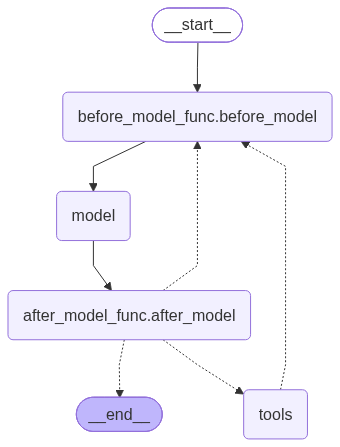

In [130]:
display(Image(data=agent.get_graph().draw_mermaid_png(), format="png"))